# Алгоритмы на основе деревьев

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Деревья решений

Деревья решений строят предсказания через цепочку простых логических вопросов. Каждая внутренняя вершина
делит объекты по условию вида «признак ≤ порог» (для числовых признаков) или «признак = значение» (для
категориальных). Алгоритм выбирает разбиение так, чтобы сделать дочерние узлы более «чистыми»: в
классификации это достигается через `gini` или `entropy`, а в регрессии — через минимизацию ошибки
(например, MSE). В листьях хранится итоговый ответ: класс или среднее значение целевой переменной.

Деревья ценят за интерпретируемость: их легко визуализировать, а важности признаков позволяют понять,
какие признаки сильнее влияют на решение. Но у одиночного дерева есть слабые места: при росте глубины оно
часто переобучается, а небольшие изменения в данных могут заметно менять структуру дерева и качество на
тесте.

![Грибы](../misc/images/mushrooms.png)

### Задание 1. Классификация грибов

Твоя задача — определить, является ли гриб ядовитым, с помощью дерева решений. Датасет Mushroom
содержит только категориальные признаки (форма, цвет, запах, текстура).

1. Загрузи датасет из файла `../datasets/mushrooms.csv`. Выдели целевую переменную `poisonous`
   и закодируй её: ядовитый = 1, съедобный = 0.
2. Преобразуй категориальные признаки с помощью `OneHotEncoder` (рекомендуется
   `handle_unknown="ignore"`).
3. Раздели данные на train/test (`test_size=0.3, random_state=42`).
4. Обучи `DecisionTreeClassifier` без ограничений. Выведи глубину дерева и количество листьев.
5. Вычисли `accuracy` на тесте. Построй матрицу ошибок (confusion matrix) в виде тепловой карты.
6. Визуализируй дерево через `plot_tree`.
7. Построй столбчатую диаграмму важности признаков (топ-10 по `feature_importances_`).

In [2]:
mushrooms = pd.read_csv("../datasets/mushrooms.csv")

mushrooms.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,poisonous
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


In [3]:
y = mushrooms["poisonous"].to_numpy()
y_encoded = []

for i in range(len(y)):
    if y[i] == 'p':
        y_encoded.append(1)
    else:
        y_encoded.append(0)

print(f"Одинаковые ли длины: {len(y) == len(y_encoded)}")
print(y[:10])
print(y_encoded[:10])

Одинаковые ли длины: True
['p' 'e' 'e' 'p' 'e' 'e' 'e' 'e' 'p' 'e']
[1, 0, 0, 1, 0, 0, 0, 0, 1, 0]


In [4]:
from sklearn.preprocessing import OneHotEncoder

X = mushrooms.drop(columns="poisonous")

encoder = OneHotEncoder(handle_unknown="ignore")

encoded_array = encoder.fit_transform(X).toarray() # encoder выдает sparse матрицу, которую нужно преобразовать в массив
encoded_columns = encoder.get_feature_names_out(X.columns)

X_encoded = pd.DataFrame(encoded_array, columns=encoded_columns)

X_encoded.head()

,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.3, random_state=42)

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Точность на тесте: {acc}")

Точность на тесте: 1.0


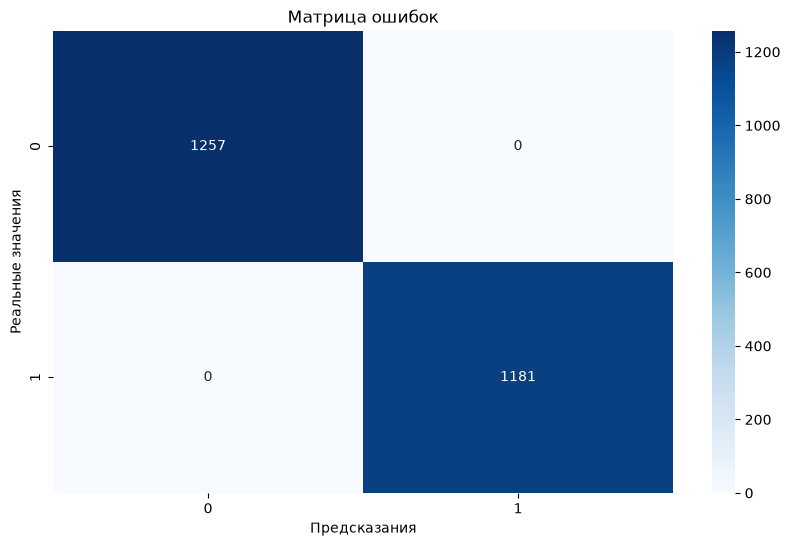

In [7]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Матрица ошибок")
plt.xlabel("Предсказания")
plt.ylabel("Реальные значения")
plt.show()

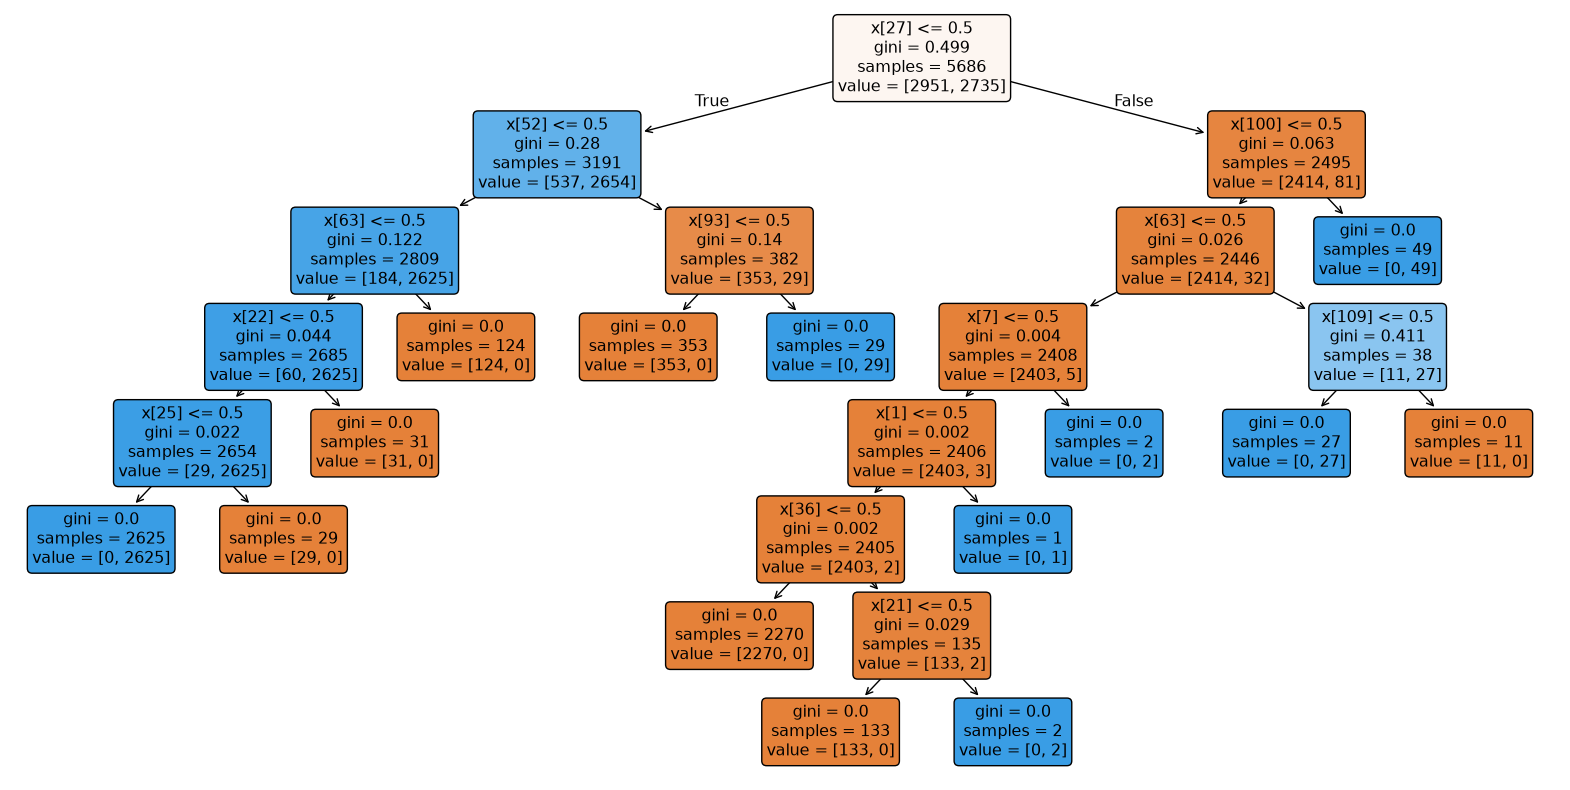

In [8]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    clf,
    filled=True,
    rounded=True
)

plt.show()

In [9]:
print("Глубина дерева:", clf.get_depth())
print("Количество листьев:", clf.get_n_leaves())

Глубина дерева: 7
Количество листьев: 14


In [10]:
features = clf.feature_names_in_.tolist()
feat_importances = clf.feature_importances_.tolist()
features_to_importance = {}

for i in range(len(features)):
    if features[i] not in features_to_importance:
        features_to_importance[features[i]] = feat_importances[i]

top_by_importance = dict(sorted(features_to_importance.items(), key=lambda item: item[1], reverse=True))

print("Топ 10 признаков по важности:")
print()

k = 0
for i, key in enumerate(top_by_importance.keys()):
    print(f"{i+1}. {key} - {top_by_importance[key]}")
    k += 1
    if k == 10:
        break

Топ 10 признаков по важности:

1. odor_n - 0.6301374723327109
2. stalk-root_c - 0.17463455444537057
3. stalk-surface-below-ring_y - 0.09303897300470451
4. spore-print-color_r - 0.032962786996095304
5. odor_a - 0.021118127906014816
6. odor_l - 0.020207226167764554
7. ring-type_n - 0.018879463796543743
8. population_y - 0.005506215034146193
9. cap-surface_g - 0.0014043189195193037
10. bruises_t - 0.0013881237452338135


### Задание 2. Gini vs Entropy

Полное дерево часто даёт `accuracy` $\approx 1.0$ на обучении и даже на тесте, но это не всегда
хорошо: такая «идеальность» может быть следствием переобучения (дерево запоминает частные случаи и
плохо переносится на новые данные). Поэтому мы ограничим глубину и сравним разные критерии разбиения.

В классификации дерево выбирает разбиение, которое уменьшает «нечистоту» узла. Пусть доля объектов
класса $k$ в узле равна $p_k = \frac{n_k}{n}$. Тогда две популярные меры нечистоты:

* $G = 1 - \sum_{k=1}^{K} p_k^2$ — индекс Джини;
* $H = - \sum_{k=1}^{K} p_k \log_2 p_k$ — Энтропия.

Критерий стремится максимизировать выигрыш $\Delta I = I(\text{parent}) -
\sum_{j=1}^{m}\frac{n_j}{n}\,I(\text{child}_j)$, где $I$ — выбранная мера.

Хотя обе меры оценивают «смешанность» классов, они по-разному реагируют на распределение $p_k$.
Из-за этого `gini` и `entropy` могут выбирать разные разбиения, строить деревья разной структуры и
давать разные свойства модели (например, компромисс между `precision` и `recall`).

1. Обучи два дерева с `max_depth=2, min_samples_leaf=5`:
   - дерево 1: `criterion="gini"`;
   - дерево 2: `criterion="entropy"`.
2. Для каждого дерева посчитай на тесте: `accuracy`, `precision`, `recall`, `F1-score`.
3. Построй матрицы ошибок обоих деревьев рядом на одном рисунке.
4. Визуализируй оба дерева рядом через `plot_tree`.
5. Ответь на вопросы:
   - Почему `gini` и `entropy` могут давать разные разбиения?
   - Что важнее в задаче определения ядовитых грибов: высокий `recall` или высокий `precision`?
   - Какой критерий ты считаешь предпочтительным для этой задачи и почему?

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score

tree1 = DecisionTreeClassifier(max_depth=2, min_samples_leaf=5, criterion="gini")
tree2 = DecisionTreeClassifier(max_depth=2, min_samples_leaf=5, criterion="entropy")

tree1.fit(X_train, y_train)
tree2.fit(X_train, y_train)

y_pred_tree1 = tree1.predict(X_test)
y_pred_tree2 = tree2.predict(X_test)

metrics_table = pd.DataFrame({
    "criterion": ["gini", "entropy"],
    "accuracy": [
        accuracy_score(y_test, y_pred_tree1),
        accuracy_score(y_test, y_pred_tree2)
    ],
    "precision": [
        precision_score(y_test, y_pred_tree1),
        precision_score(y_test, y_pred_tree2)
    ],
    "recall": [
        recall_score(y_test, y_pred_tree1),
        recall_score(y_test, y_pred_tree2)
    ],
    "f1_score": [
        f1_score(y_test, y_pred_tree1),
        f1_score(y_test, y_pred_tree2)
    ]
})

metrics_table

,criterion,accuracy,precision,recall,f1_score
0,gini,0.947908,0.917591,0.980525,0.948015
1,entropy,0.922067,1.000000,0.839119,0.912523


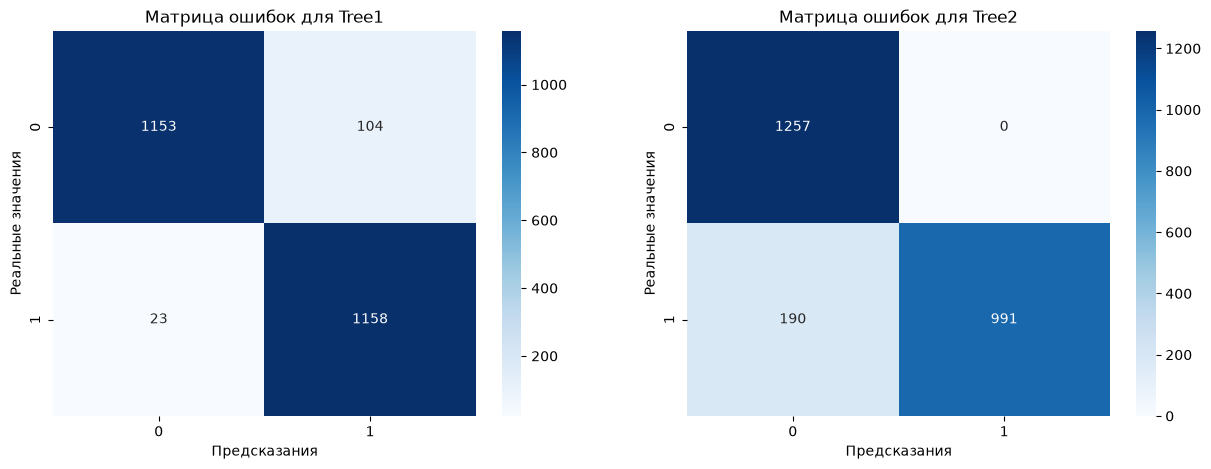

In [12]:
cm1 = confusion_matrix(y_test, y_pred_tree1)
cm2 = confusion_matrix(y_test, y_pred_tree2)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues')
plt.title("Матрица ошибок для Tree1")
plt.xlabel("Предсказания")
plt.ylabel("Реальные значения")

plt.subplot(1, 2, 2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues')
plt.title("Матрица ошибок для Tree2")
plt.xlabel("Предсказания")
plt.ylabel("Реальные значения")

plt.show()

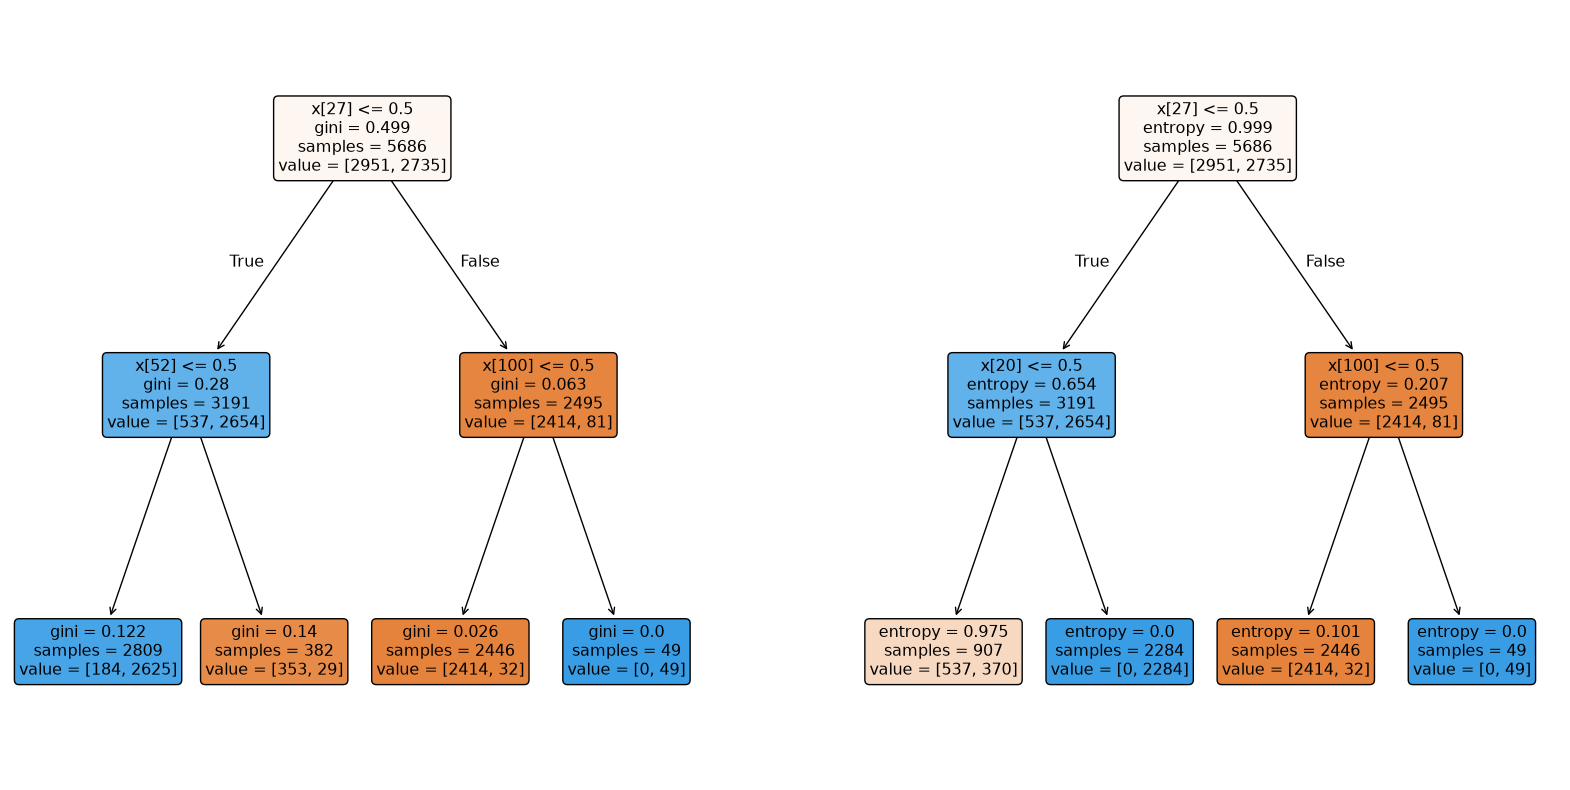

In [13]:
plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plot_tree(
    tree1,
    filled=True,
    rounded=True
)

plt.subplot(1, 2, 2)
plot_tree(
    tree2,
    filled=True,
    rounded=True
)

plt.show()

#### Почему `gini` и `entropy` могут давать разные разбиения?

Индекс Джини и энтропия измеряют «нечистоту» узла по-разному.

- `gini` лучше работает в ситуации, когда один класс доминирует, и стремится к более «жёстким» разбиениям.
- `entropy` чувствительнее к редким классам и даёт более «сбалансированные» разбиения, особенно при неравномерных распределениях.

Из-за этого деревья с разными критериями могут выбирать разные признаки для разбиений.
Например, `entropy` может предпочесть признак, который лучше разделяет редкие случаи, а `gini` — тот, который быстрее уменьшает общую нечистоту.

#### Что важнее в задаче определения ядовитых грибов: recall или precision?

Ошибка пропуска ядовитого гриба (false negative) опаснее, чем ошибка ложного срабатывания.

Поэтому при классификации грибов важнее высокий recall — чтобы модель находила все ядовитые экземпляры, даже если иногда ошибается и помечает съедобный как ядовитый.

Иными словами: лучше перестраховаться, чем пропустить опасный гриб.

#### Какой критерий предпочтителен и почему?
На матрицах ошибок видно:

- Tree1 (`gini`) делает меньше пропусков ядовитых грибов → выше recall.
- Tree2 (`entropy`) даёт меньше ложных тревог → выше precision, но пропускает больше ядовитых грибов.

Для этой задачи предпочтителен критерий `Gini`, потому что он минимизирует риск пропуска опасных объектов.
Даже если точность немного ниже, безопасность важнее.

### Задание 3. Предсказание уровня преступности

Деревья решений подходят не только для классификации, но и для регрессии. В регрессионном дереве в
каждом листе хранится числовой прогноз (обычно среднее значение целевой переменной по объектам листа),
а качество оценивают с помощью MSE, MAE и $R^2$.

Загрузи датасет Communities and Crime из файла `../datasets/communities_and_crime.csv`. Целевая переменная
— `ViolentCrimesPerPop`.

1. Предобработка:
   - удали нечисловые столбцы: `state`, `county`, `community`, `communityname`, `fold`;
   - приведи остальные столбцы к числовому типу;
   - удали столбцы, где доля пропусков больше 80%;
   - заполни оставшиеся пропуски медианой;
   - затем раздели данные на train/test (`test_size=0.2, random_state=42`).
2. Базовая модель без ограничений: обучи `DecisionTreeRegressor`. Выведи MSE, MAE, R² на train и test. Объясни разрыв между train- и test-метриками.
3. Ручная настройка: попробуй `max_depth=7, min_samples_split=10, min_samples_leaf=10`.
   Выведи Test MSE, MAE, R².
4. `GridSearchCV`: перебери сетку параметров (`max_depth`, `min_samples_split`,
   `min_samples_leaf`), `cv=5`. Выведи лучшие параметры и метрики.
5. Визуализируй дерево без ограничений и лучшее дерево рядом через `plot_tree`.

In [14]:
df = pd.read_csv("../datasets/communities_and_crime.csv")

df.shape

(1994, 128)

In [15]:
cols_to_drop = ["state", "county", "community", "communityname", "fold"]
df = df.drop(columns=cols_to_drop)
df = df.apply(pd.to_numeric, errors="coerce")
null_fraction = df.isna().mean()
cols_to_keep = null_fraction[null_fraction < 0.8].index

df = df[cols_to_keep]
df.shape

(1994, 101)

In [16]:
df = df.fillna(df.median())

y = df["ViolentCrimesPerPop"]
X = df.drop(columns=["ViolentCrimesPerPop"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

tree_base = DecisionTreeRegressor()
tree_base.fit(X_train, y_train)

y_pred_train = tree_base.predict(X_train)
y_pred_test = tree_base.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("Train MSE:", mse_train)
print("Train MAE:", mae_train)
print("Train R²:", r2_train)

print("\nTest MSE:", mse_test)
print("Test MAE:", mae_test)
print("Test R²:", r2_test)

Train MSE: 5.886462996167884e-36
Train MAE: 3.0017785540413714e-19
Train R²: 1.0

Test MSE: 0.031231829573934836
Test MAE: 0.11531328320802006
Test R²: 0.34792060664041746


In [18]:
tree_upd = DecisionTreeRegressor(max_depth=7, min_samples_split=10, min_samples_leaf=10)

tree_upd.fit(X_train, y_train)

y_pred_tree_upd = tree_upd.predict(X_test)

mse_tree_upd = mean_squared_error(y_test, y_pred_tree_upd)
mae_tree_upd = mean_absolute_error(y_test, y_pred_tree_upd)
r2_tree_upd = r2_score(y_test, y_pred_tree_upd)

print("\nTest MSE:", mse_tree_upd)
print("Test MAE:", mae_tree_upd)
print("Test R²:", r2_tree_upd)


Test MSE: 0.02559727147745251
Test MAE: 0.10403911840939736
Test R²: 0.4655627453023766


In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [5, 7, 9, 11],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf": [5, 10, 20]
}

tree = DecisionTreeRegressor(random_state=42)

grid = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Лучшие параметры:", grid.best_params_)
print("Лучший CV R²:", grid.best_score_)

best_tree = grid.best_estimator_

y_pred_test_best = best_tree.predict(X_test)

print("Test MSE:", mean_squared_error(y_test, y_pred_test_best))
print("Test MAE:", mean_absolute_error(y_test, y_pred_test_best))
print("Test R²:", r2_score(y_test, y_pred_test_best))

Лучшие параметры: {'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 5}
Лучший CV R²: 0.5692849787765194
Test MSE: 0.02176553745177805
Test MAE: 0.09900475697823474
Test R²: 0.5455642960620646


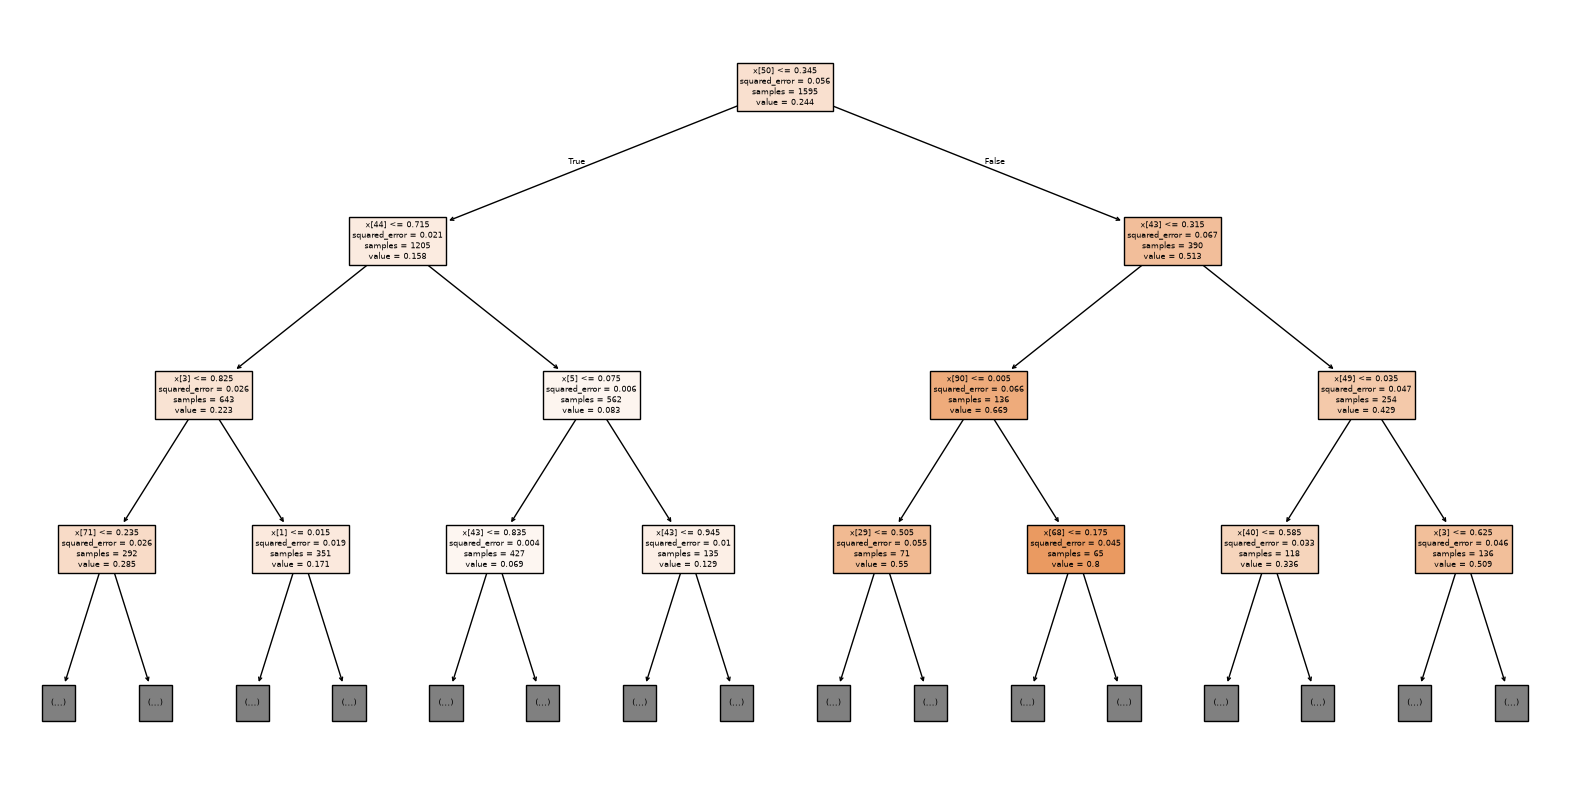

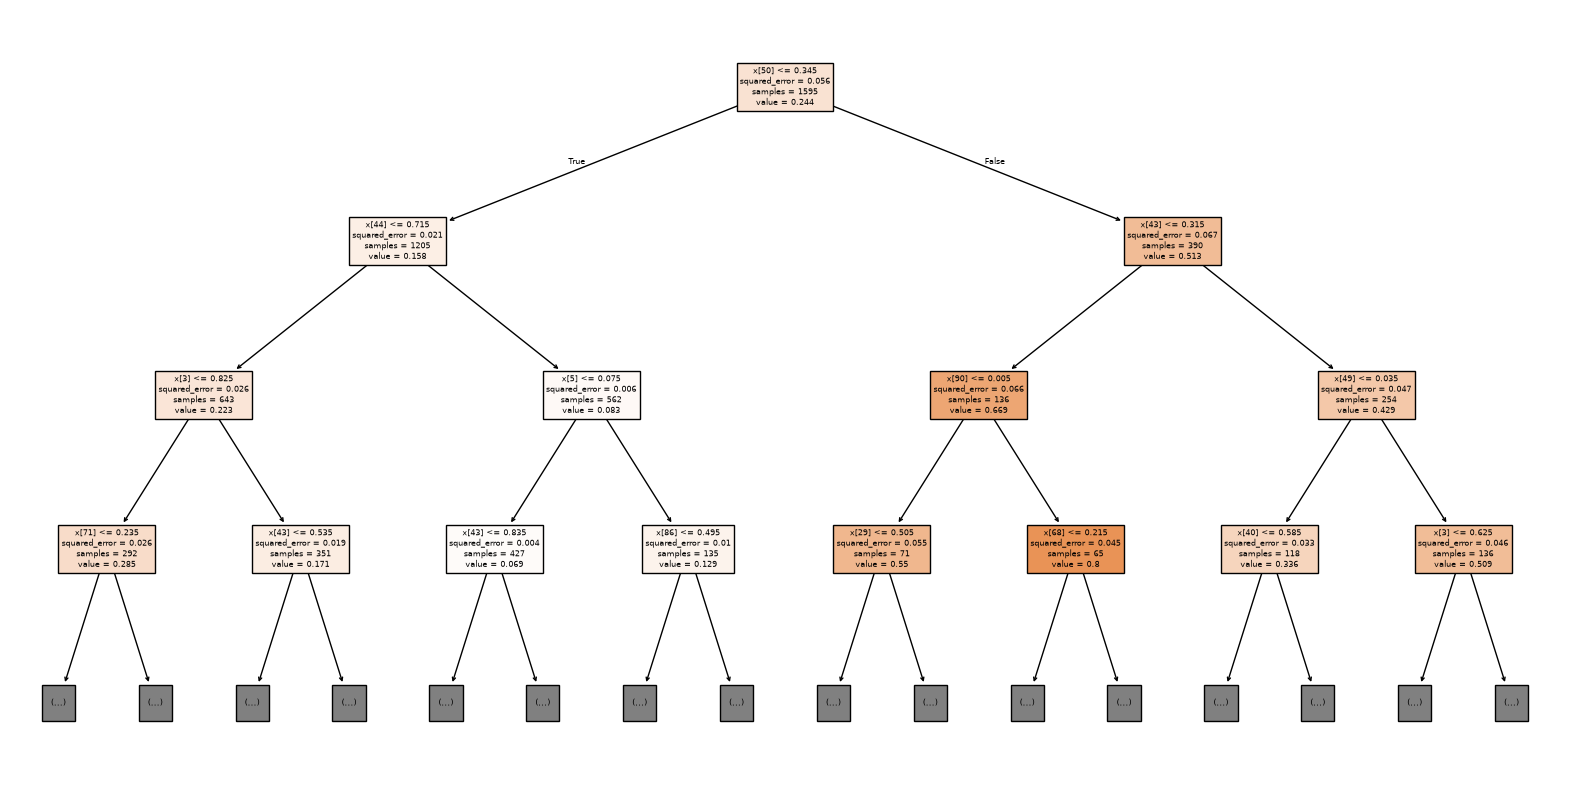

In [20]:
plt.figure(figsize=(20, 10))
plt.title("Полное дерево (без ограничений)")
plot_tree(tree_base, filled=True, max_depth=3)  # ограничиваем глубину отображения
plt.show()

plt.figure(figsize=(20, 10))
plt.title("Лучшее дерево (GridSearchCV)")
plot_tree(best_tree, filled=True, max_depth=3)
plt.show()

### Задание 4. Нестабильность деревьев решений

Одна из ключевых проблем одиночных деревьев — нестабильность (высокая дисперсия): небольшие изменения в
обучающих данных могут приводить к заметно другой структуре дерева и заметно другим метрикам на тесте. В этом задании ты проверишь это экспериментально.

Используй данные из Задания 3. Покажи, что одиночное дерево чувствительно к малым изменениям в обучающей выборке.

1. Базовое дерево: обучи `DecisionTreeRegressor` без ограничений на полном `X_train`.
   Выведи глубину, количество листьев, количество узлов и MSE на тесте.
2. Эксперимент 1: удали случайные 10% строк из `X_train`, обучи новое дерево.
   Выведи те же характеристики и MSE  на тесте.
3. Эксперимент 2: добавь гауссовский шум (`std=0.05`) ко всем признакам `X_train`,
   обучи ещё одно дерево. Выведи характеристики и MSE на тесте.
4. Напиши выводы по результатам экспериментов:
   - Изменились ли структура и качество деревьев при малых изменениях данных?
   - Почему одиночное дерево нестабильно?

In [21]:
base_tree = DecisionTreeRegressor()

base_tree.fit(X_train, y_train)

y_pred = base_tree.predict(X_test)

print("Глубина дерева:", base_tree.get_depth())
print("Кол-во листьев:", base_tree.get_n_leaves())
print("Кол-во узлов:", base_tree.tree_.node_count)
print("MSE на тесте:", mean_squared_error(y_test, y_pred))

Глубина дерева: 24
Кол-во листьев: 1205
Кол-во узлов: 2409
MSE на тесте: 0.03607293233082707


In [22]:
percent = 0.1
n_drop = int(len(X_train) * percent)

X_train_top_removed = X_train.iloc[n_drop:].reset_index(drop=True)
y_train_top_removed = y_train.iloc[n_drop:].reset_index(drop=True)

top_removed_tree = DecisionTreeRegressor()

top_removed_tree.fit(X_train_top_removed, y_train_top_removed)

y_pred_top_removed = top_removed_tree.predict(X_test)

print("Удалил 10% строк из датасета")
print()

print("Глубина дерева:", top_removed_tree.get_depth())
print("Кол-во листьев:", top_removed_tree.get_n_leaves())
print("Кол-во узлов:", top_removed_tree.tree_.node_count)
print("MSE на тесте:", mean_squared_error(y_test, y_pred_top_removed))

Удалил 10% строк из датасета

Глубина дерева: 26
Кол-во листьев: 1090
Кол-во узлов: 2179
MSE на тесте: 0.03388872180451129


In [23]:
def add_gaussian_noise(df, mean=0.0, std_dev=1.0, columns=None, random_state=None):
    """
    Добавляет гауссовский шум в датафрейм.

    Parameters:
        df (pd.DataFrame): Датафрейм.
        mean (float): Среднее значение.
        std_dev (float): Стадартное отклонение.
        columns (list or None): Список столбцов. Если ничего не указывать, то по умолчанию берутся все стольцы.
        random_state (int or None): Воспроспроизводимость.

    Returns:
        pd.DataFrame: Новый датафрейм с шумом.
    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError("Требуемый тип: pandas DataFrame.")

    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns.tolist()

    if not columns:
        raise ValueError("В датафрейме не столбцов.")

    noisy_df = df.copy()

    rng = np.random.default_rng(seed=random_state)

    for col in columns:
        if col not in noisy_df.columns:
            raise ValueError(f"Столбец '{col}' не найден.")
        if not np.issubdtype(noisy_df[col].dtype, np.number):
            raise TypeError(f"Столбец '{col}' не содержит числовых значений.")

        noise = rng.normal(loc=mean, scale=std_dev, size=noisy_df[col].shape)
        noisy_df[col] = noisy_df[col] + noise

    return noisy_df


y_train_pd = pd.DataFrame(y_train)

X_train_noisy = add_gaussian_noise(X_train)
y_train_noisy = add_gaussian_noise(y_train_pd)

noisy_tree = DecisionTreeRegressor()

noisy_tree.fit(X_train_noisy, y_train_noisy)

y_pred_noisy = noisy_tree.predict(X_test)

print("Добавил шум")
print()

print("Глубина дерева:", noisy_tree.get_depth())
print("Кол-во листьев:", noisy_tree.get_n_leaves())
print("Кол-во узлов:", noisy_tree.tree_.node_count)
print("MSE на тесте:", mean_squared_error(y_test, y_pred_noisy))

Добавил шум

Глубина дерева: 30
Кол-во листьев: 1595
Кол-во узлов: 3189
MSE на тесте: 0.9174587118712317


Можно заметить, что при удалении сторок и добавлении шума в датасет глубина дерева увеличилась. Это характерно для обоих экспериментов.

Количество листьев в первом эксперименте уменьшилось примерно на 100, а во втором увеличилось на 300. Количестов узлов ведет себя также - в первом случае уменьшается, во втором значительно увеличивается.

Средняя квадратическая ошибка посравнению с обычным деревом при удалении строк почти не изменилась(возможно, чтобы разница была заметной, нужно удалить больше строк). А вот при добавлении шума резко увеличилась, причем кратно.

Все эти наблюдения доказывают, что одиночное дерево не стабильно. Особенно в случае с добавлением шума.

## Ансамбли на деревьях

Мы только что увидели, насколько сильно может измениться дерево решений даже при минимальных изменениях в обучающих данных, например, при:
- удалении всего 10% объектов;
- добавлении небольшого шума.

При этом меняется:
- структура дерева (глубина, первые разбиения, количество листьев и узлов);
- качество на тестовой выборке.

Это происходит потому, что алгоритм построения дерева **жадный** и **детерминированный**

В результате одиночное дерево:
- очень чувствительно к шуму и выбросам;
- склонно к переобучению (запоминает обучающие данные, включая шум);
- даёт нестабильные предсказания при небольших изменениях выборки.

**Как бороться с этой неустойчивостью?**

**Ансамбли** — это подход, когда мы обучаем **много** слабых моделей и комбинируем их предсказания.  
Идея проста: если каждая модель ошибается по-своему, то их усреднение (или голосование) даёт гораздо более стабильный и точный результат.

**Основные виды ансамблей:**

1. **Blending**  
   - Обучаем несколько разных моделей (часто разных семейств).  
   - Строим итоговый прогноз как взвешенную комбинацию их предсказаний.  
   - Веса можно подобрать на валидации (или обучить простую мета-модель).  

2. **Committee**  
   - «Комитет» — это набор моделей, которые голосуют или усредняются.  
   - Частный случай — ансамбли одного типа (например, много деревьев), но комитетом могут быть и разные модели.  

3. **MoE (Mixture of Experts)**  
   - Несколько «экспертов» специализируются на разных типах объектов.  
   - Отдельная модель (gating) выбирает эксперта или задаёт веса экспертов для каждого объекта.
   - Сейчас MoE-архитектуры активно используются в LLM, чтобы масштабировать модель эффективнее по вычислениям.  

4. **Bagging (Bootstrap Aggregating)**  
   - Обучаем много моделей на **разных** подвыборках данных.  
   - Каждая подвыборка — бутстреп (выборка с возвращением того же размера).  
   - Для регрессии: усредняем предсказания всех моделей.  
   - Для классификации: голосуем большинством.  

5. **Random Forest** — улучшенный Bagging  
   - К бутстрепу добавляется ещё один слой случайности: при каждом разбиении узла берётся **случайное подмножество признаков**.
   - Деревья становятся менее похожими друг на друга → их ошибки лучше компенсируют друг друга.  

**Почему ансамбли работают лучше одиночного дерева?**

- **Разнообразие моделей** → ошибки разных деревьев компенсируют друг друга.  
- **Усреднение/голосование** → снижает влияние шума и выбросов.  
- **Снижение дисперсии** без сильного роста смещения.  

![Голосование](../misc/images/vote.png)

### Задание 5. Blending

**Blending** — простейший способ построить ансамбль: обучить несколько **разных** моделей и скомбинировать их предсказания. Если модели делают разные ошибки, их усреднение даёт более точный и стабильный результат.

Продолжай работать с датасетом Communities and Crime из Задания 3.

1. Обучи три модели на `X_train`, `y_train`:
   - `DecisionTreeRegressor` (лучшие параметры из Задания 3);
   - `Ridge` (с параметрами по умолчанию);
   - `KNeighborsRegressor` (`n_neighbors=10`).
2. Получи предсказания каждой модели на тестовой выборке. Для каждой посчитай MSE, MAE, R².
3. Построй блендинг с равными весами: `y_blend = (y_dt + y_ridge + y_knn) / 3`.
   Посчитай MSE, MAE, R² блендинга.
4. Подбери веса блендинга: перебери комбинации весов (с шагом 0.1, сумма = 1)
   и найди комбинацию, при которой MSE на тесте минимальна.
   Посчитай MSE, MAE, R² для лучшего взвешенного блендинга.
5. Составь сводную таблицу: три модели / равный блендинг / лучший взвешенный блендинг
   (столбцы: MSE, MAE, R²).

In [24]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor

dt = DecisionTreeRegressor(max_depth = 5, min_samples_leaf = 20, min_samples_split = 5)
ridge = Ridge()
knn = KNeighborsRegressor(n_neighbors=10)

dt.fit(X_train, y_train)
ridge.fit(X_train, y_train)
knn.fit(X_train, y_train)

y_dt = dt.predict(X_test)
y_ridge = ridge.predict(X_test)
y_knn = knn.predict(X_test)

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def metrics(y_true, y_pred):
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

m_dt = metrics(y_test, y_dt)
m_ridge = metrics(y_test, y_ridge)
m_knn = metrics(y_test, y_knn)

In [26]:
print("Tree", m_dt)
print("Ridge", m_ridge)
print("KNN", m_knn)

Tree {'MSE': 0.021765537451778054, 'MAE': 0.09900475697823476, 'R2': 0.5455642960620646}
Ridge {'MSE': 0.01728614176828457, 'MAE': 0.09303032801201012, 'R2': 0.6390881676942177}
KNN {'MSE': 0.01864115538847118, 'MAE': 0.0937218045112782, 'R2': 0.6107972711473608}


In [27]:
y_blend_equal = (y_dt + y_ridge + y_knn) / 3
m_blend_equal = metrics(y_test, y_blend_equal)

print("Blend", m_blend_equal)

Blend {'MSE': 0.017229017312675173, 'MAE': 0.09029464916668756, 'R2': 0.6402808509557472}


In [28]:
best_mse = float("inf")
best_weights = None
best_pred = None

weights = np.arange(0, 1.1, 0.1)

for w1 in weights:
    for w2 in weights:
        w3 = 1 - w1 - w2
        if w3 < 0:
            continue
        
        y_blend = w1*y_dt + w2*y_ridge + w3*y_knn
        mse = mean_squared_error(y_test, y_blend)
        
        if mse < best_mse:
            best_mse = mse
            best_weights = (w1, w2, w3)
            best_pred = y_blend

m_blend_best = metrics(y_test, best_pred)
best_weights

(np.float64(0.0),
 np.float64(0.6000000000000001),
 np.float64(0.3999999999999999))

In [29]:
results = pd.DataFrame({
    "Model": [
        "DecisionTree (best)",
        "Ridge",
        "KNN (k=10)",
        "Equal Blend",
        "Best Weighted Blend"
    ],
    "MSE": [
        m_dt["MSE"],
        m_ridge["MSE"],
        m_knn["MSE"],
        m_blend_equal["MSE"],
        m_blend_best["MSE"]
    ],
    "MAE": [
        m_dt["MAE"],
        m_ridge["MAE"],
        m_knn["MAE"],
        m_blend_equal["MAE"],
        m_blend_best["MAE"]
    ],
    "R2": [
        m_dt["R2"],
        m_ridge["R2"],
        m_knn["R2"],
        m_blend_equal["R2"],
        m_blend_best["R2"]
    ]
})

results


,Model,MSE,MAE,R2
0,DecisionTree (best),0.021766,0.099005,0.545564
1,Ridge,0.017286,0.093030,0.639088
2,KNN (k=10),0.018641,0.093722,0.610797
3,Equal Blend,0.017229,0.090295,0.640281
4,Best Weighted Blend,0.016589,0.089280,0.653652


### Задание 6. Bagging (Bootstrap Aggregating)

**Bagging** — ансамбль из моделей **одного типа**, обученных на разных **бутстреп-выборках**
(выборках с возвращением). В отличие от блендинга, разнообразие создаётся не разными алгоритмами,
а разными подмножествами данных.

1. Ручной бэггинг:
   - Создай 50 бутстреп-выборок из `X_train` (выборка с возвращением того же размера).
   - На каждой обучи `DecisionTreeRegressor` без ограничений.
   - Усредни предсказания всех 50 деревьев на `X_test`.
   - Посчитай MSE, MAE, R² ручного бэггинга.
2. BaggingRegressor из sklearn:
   - Обучи `BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=50, random_state=42)`.
   - Посчитай MSE, MAE, R². Совпадают ли результаты с ручной реализацией?
3. Зависимость от числа деревьев:
   - Обучи `BaggingRegressor` с `n_estimators` от 1 до 200 (шаг 10).
   - Построй график: MSE на тесте в зависимости от числа деревьев.
   - При каком числе деревьев качество выходит на плато?
4. Составь сводную таблицу: лучшее одиночное дерево (из Задания 3) / ручной бэггинг / sklearn бэггинг
   (столбцы: MSE, MAE, R²).
5. Вывод: объясни, что такое бутстреп-выборка и почему бэггинг снижает дисперсию, но почти не
   влияет на смещение. Чем бэггинг отличается от блендинга?

In [30]:
n_estimator = 50
predictions = []

for i in range(n_estimator):
    # бутстреп-индексы
    indices = np.random.choice(len(X_train), size=len(X_train), replace=True)

    X_boot = X_train.iloc[indices]
    y_boot = y_train.iloc[indices]

    tree = DecisionTreeRegressor(random_state=i)
    tree.fit(X_boot, y_boot)

    pred = tree.predict(X_test)
    predictions.append(pred)

y_bag = np.mean(predictions, axis=0)

mse = mean_squared_error(y_test, y_bag)
mae = mean_absolute_error(y_test, y_bag)
r2 = r2_score(y_test, y_bag)

print("Ручной bagging:")
print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)

Ручной bagging:
MSE: 0.01876422967418546
MAE: 0.09453583959899751
R2: 0.6082276424492805


In [31]:
from sklearn.ensemble import BaggingRegressor

bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(), # сюда передается экземпляр модели, а не класс
    n_estimators=50,
    random_state=42
)

bag.fit(X_train, y_train)

y_bag_sklearn = bag.predict(X_test)

mse = mean_squared_error(y_test, y_bag_sklearn)
mae = mean_absolute_error(y_test, y_bag_sklearn)
r2 = r2_score(y_test, y_bag_sklearn)

print("Bagging из sklearn:")
print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)

Bagging из sklearn:
MSE: 0.018531203107769425
MAE: 0.09393834586466165
R2: 0.6130929296943176


Результаты получились очень похожими на ручную реализацию

In [32]:
x_line = []
y_line = []

for i in range(1, 201):
    bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=i,
    random_state=42
    )

    bag.fit(X_train, y_train)
    y_bag_sklearn = bag.predict(X_test)
    mse = mean_squared_error(y_test, y_bag_sklearn)

    x_line.append(i)
    y_line.append(mse)

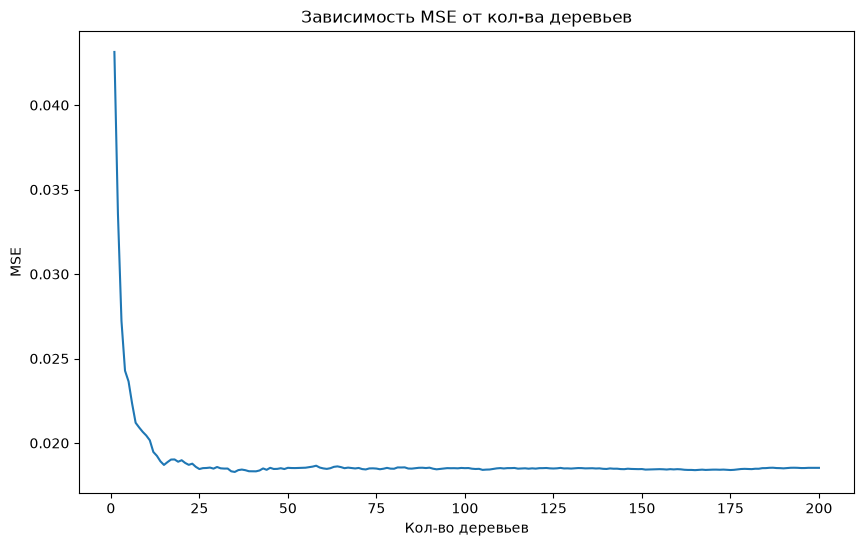

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(x_line, y_line)
plt.title("Зависимость MSE от кол-ва деревьев")
plt.xlabel("Кол-во деревьев")
plt.ylabel("MSE")

plt.show()

На графике видно, что ошибка MSE резко падает при увеличении числа деревьев от 1 до примерно 30,
а затем выходит на плато около 0.019.
Это означает, что добавление новых деревьев после этого почти не улучшает качество — ансамбль уже стабилизировался.

- Дисперсия — это чувствительность модели к случайным изменениям данных.
Одиночное дерево имеет высокую дисперсию: небольшие изменения в данных → сильно меняется структура дерева.
Усреднение предсказаний многих деревьев сглаживает эти колебания → дисперсия падает.
- Смещение (bias) — систематическая ошибка модели.
Все деревья обучаются на похожих данных и имеют одинаковый тип модели,
поэтому их среднее предсказание имеет примерно то же смещение, что и одно дерево.

Бэггинг уменьшает разброс предсказаний (дисперсию), но не делает модель «умнее» — смещение остаётся прежним.

### Задание 7. Random Forest

Random Forest — это улучшенный бэггинг: к бутстреп-выборкам добавляется ещё один слой случайности –
**случайный выбор признаков** при каждом разбиении узла. Это делает деревья менее коррелированными
и ещё сильнее снижает дисперсию ансамбля.

1. Обучи `RandomForestRegressor` с параметрами по умолчанию (`n_estimators=100, random_state=42`).
   Посчитай MSE, MAE, R² на тесте. Сравни с бэггингом из Задания 6.
2. Подбор гиперпараметров: используй `GridSearchCV` (`cv=5, scoring='neg_mean_squared_error'`) для перебора:
   - `n_estimators`: [100, 300];
   - `max_depth`: [15, 20, None];
   - `max_features`: ['sqrt', 0.3];
   - `min_samples_leaf`: [1, 3, 5].  
   Выведи лучшие параметры.
3. Посчитай MSE, MAE, R² для лучшей модели на тесте.
4. Важность признаков:
   - Построй горизонтальную столбчатую диаграмму топ-15 признаков по `feature_importances_`.
   - Вычисли `permutation_importance` на тестовой выборке (`n_repeats=10, random_state=42`).
   - Построй горизонтальную столбчатую диаграмму топ-15 признаков рядом с первой.
   - Выведи топ-5 признаков по каждому методу.
5. Составь итоговую сводную таблицу: одиночное дерево / бэггинг / Random Forest
   (столбцы: MSE, MAE, R²).

In [34]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor(n_estimators=100, random_state=42)

forest.fit(X_train, y_train)
pred = forest.predict(X_test)

m_forest = metrics(y_test, pred)
print("Forest metrics:", m_forest)

Forest metrics: {'MSE': 0.01834792769423559, 'MAE': 0.09230551378446114, 'R2': 0.6169194785102283}


In [35]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [15, 20, None],
    "max_features": ['sqrt', 0.3],
    "min_samples_leaf": [1, 3, 5]
}

grid = GridSearchCV(
    estimator=forest,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Лучшие параметры:", grid.best_params_)

best_forest = grid.best_estimator_

pred_best = best_forest.predict(X_test)
m_forest_best = metrics(y_test, pred_best)
print("Best metrics:", m_forest_best)

Лучшие параметры: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 300}
Best metrics: {'MSE': 0.017555357136686205, 'MAE': 0.09065996574870763, 'R2': 0.6334673060122327}


In [36]:
importances = best_forest.feature_importances_
features = X_train.columns

indices = np.argsort(importances)[::-1][:15]
top_features = features[indices]
top_values = importances[indices]

In [37]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_forest, X_test, y_test,
    n_repeats=10, random_state=42,
)

perm_importances = perm.importances_mean
indices_perm = np.argsort(perm_importances)[::-1][:15]
top_features_perm = features[indices_perm]
top_values_perm = perm_importances[indices_perm]

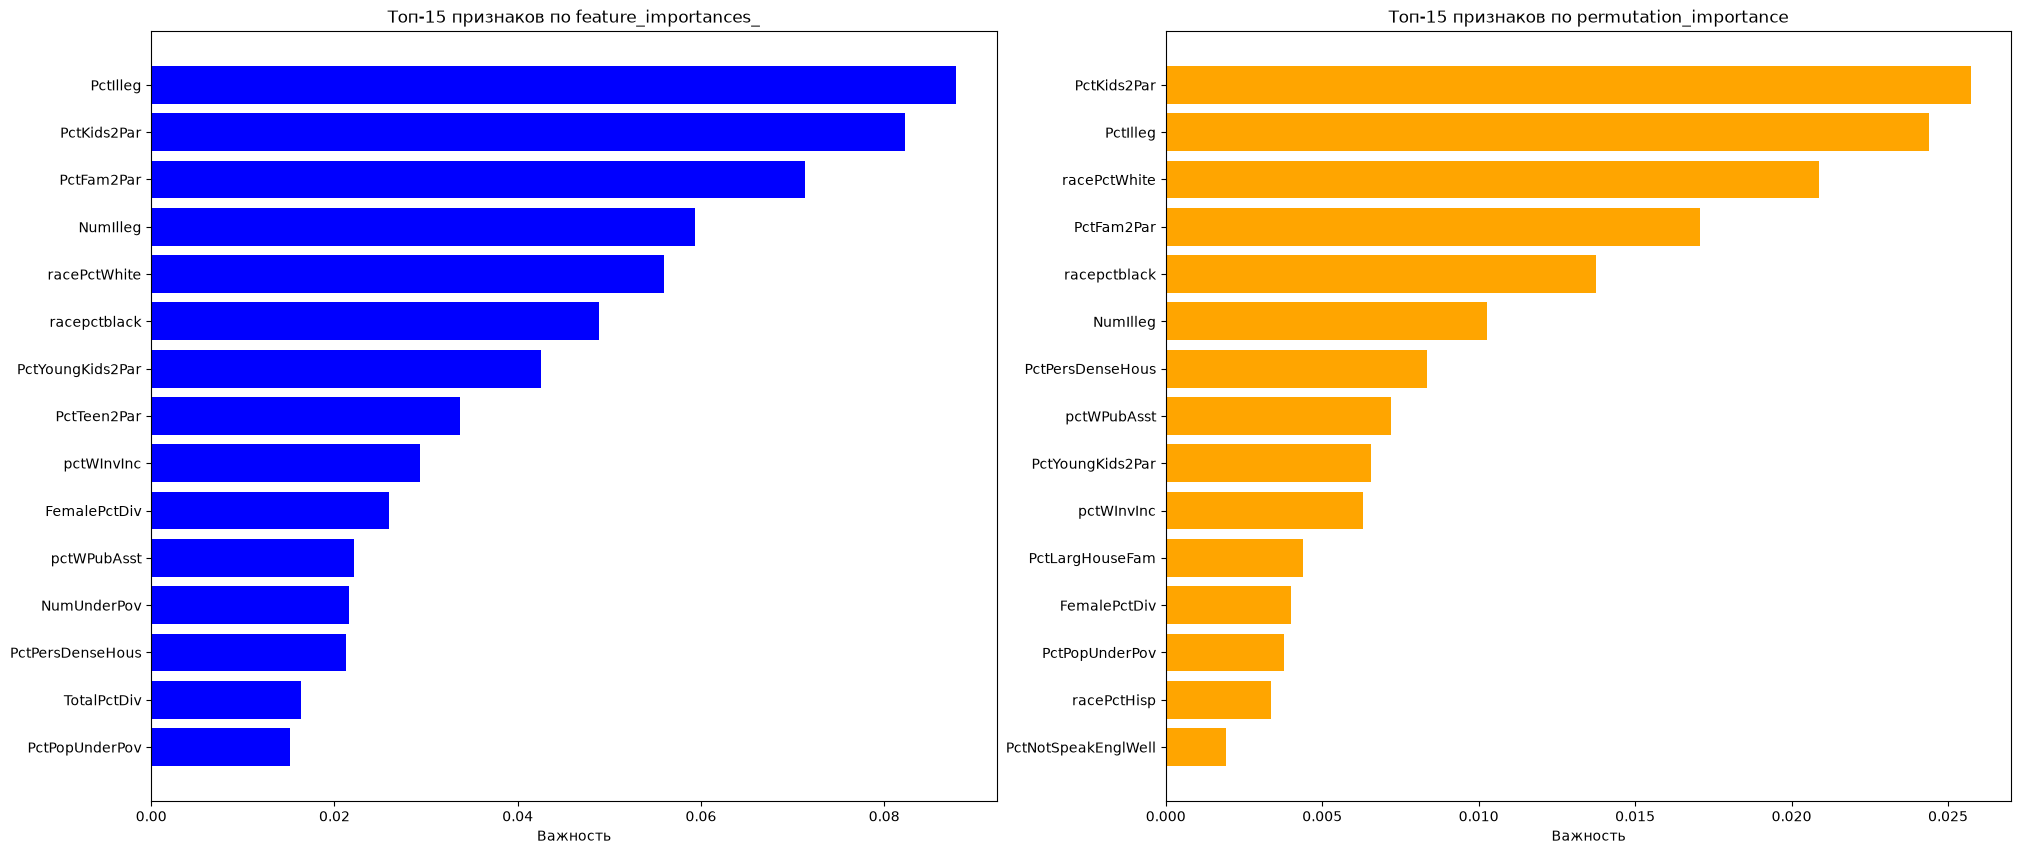

In [38]:
plt.figure(figsize=(24, 10))

plt.subplot(1, 2, 1)
plt.barh(top_features[::-1], top_values[::-1], color="blue")
plt.title("Топ‑15 признаков по feature_importances_")
plt.xlabel("Важность")

plt.subplot(1, 2, 2)
plt.barh(top_features_perm[::-1], top_values_perm[::-1], color="orange")
plt.title("Топ‑15 признаков по permutation_importance")
plt.xlabel("Важность")

plt.show()

In [39]:
print("Топ‑5 по feature_importances_:", list(top_features[:5]))
print("Топ‑5 по permutation_importance:", list(top_features_perm[:5]))


Топ‑5 по feature_importances_: ['PctIlleg', 'PctKids2Par', 'PctFam2Par', 'NumIlleg', 'racePctWhite']
Топ‑5 по permutation_importance: ['PctKids2Par', 'PctIlleg', 'racePctWhite', 'PctFam2Par', 'racepctblack']


In [40]:
m_base_tree = metrics(y_test, y_pred_test_best)
m_bagging = metrics(y_test, y_bag_sklearn)

results = pd.DataFrame({
    "Дерево": [
        "Одиночное дерево",
        "Bagging",
        "Random Forest",
    ],
    "MSE": [
        m_base_tree["MSE"],
        m_bagging["MSE"],
        m_forest_best["MSE"],
    ],
    "MAE": [
        m_base_tree["MAE"],
        m_bagging["MAE"],
        m_forest_best["MAE"], 
    ],
    "R2": [
        m_base_tree["R2"],
        m_bagging["R2"],
        m_forest_best["R2"],
    ]
})

results

,Дерево,MSE,MAE,R2
0,Одиночное дерево,0.021766,0.099005,0.545564
1,Bagging,0.018530,0.093567,0.613125
2,Random Forest,0.017555,0.090660,0.633467


### Задание 8. OOB-score

OOB-score (Out-of-Bag score) — уникальная особенность бэггинга и Random Forest: каждый объект
обучающей выборки примерно в 37% деревьев не попадает в бутстреп-выборку. Предсказание для него
можно получить, усреднив ответы только тех деревьев, которые его **не видели**. Это даёт оценку
качества модели **без отдельной валидации**.

1. Обучи лучший `RandomForestRegressor` с `oob_score=True`. Выведи `oob_score_`.
2. Сравни `oob_score_` с Test R². Насколько OOB-score близок к тест-метрике?
3. Стабильность OOB-score: обучи 10 моделей с разными `random_state` (от 1 до 100 с шагом 10).
   Собери все `oob_score_`, выведи среднее и стандартное отклонение.
4. Построй график: OOB-score для каждого `random_state` (точки) и горизонтальную линию Test R².

In [41]:
best_forest = RandomForestRegressor(
    max_depth=None,
    max_features='sqrt',
    min_samples_leaf=3,
    n_estimators=300,
    oob_score=True
)

best_forest.fit(X_train, y_train)
y_pred_best = best_forest.predict(X_test)

print("oob_score:", best_forest.oob_score_)
print("R2:", r2_score(y_test, y_pred_best))


oob_score: 0.6696347643927674
R2: 0.629740401666689


Разница между `r2_score` и `oob_score` на тестовых данных примерно 0.04.

In [42]:
oob_list = []
r2_list = []
random_state = []

for rs in range(1, 101, 10):
    random_state.append(rs)

    forest = RandomForestRegressor(
        max_depth=None,
        max_features='sqrt',
        min_samples_leaf=3,
        n_estimators=300,
        oob_score=True,
        random_state=rs
    )
    forest.fit(X_train, y_train)
    y_pred = forest.predict(X_test)

    oob_list.append(forest.oob_score_)
    r2_list.append(r2_score(y_test, y_pred))


In [43]:
print("Средний OOB-score:", np.mean(oob_list))
print("Стандартное отклонение:", np.std(oob_list))


Средний OOB-score: 0.6705748621557
Стандартное отклонение: 0.0010786356670810524


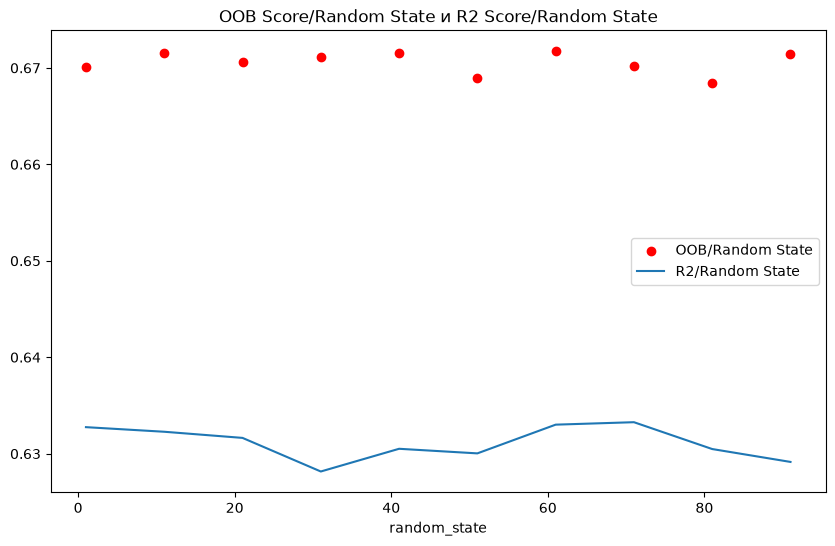

In [44]:
plt.figure(figsize=(10, 6))

plt.scatter(random_state, oob_list, color="red", label="OOB/Random State")
plt.plot(random_state, r2_list, label="R2/Random State")
plt.xlabel("random_state")
plt.title("OOB Score/Random State и R2 Score/Random State")
plt.legend()

plt.show()

## Градиентный бустинг

Градиентный бустинг строит ансамбль деревьев последовательно: каждое новое дерево учится исправлять
ошибки предыдущих. На практике это один из самых сильных подходов для табличных данных, потому что
он хорошо балансирует смещение и дисперсию и умеет «добирать» сложные нелинейные зависимости.

У бустинга есть разные популярные реализации: LightGBM, XGBoost и CatBoost. В этом проекте ты будешь
использовать **CatBoost** — библиотеку, которая нативно работает с категориальными признаками и часто
даёт высокое качество «из коробки».

*Твоя задача*: прогнозирование ежедневных продаж 1115 магазинов сети Rossmann. В данных есть история продаж
по датам, признаки промо-активностей и праздников, а также характеристики магазинов (тип, ассортимент,
конкуренты, интервалы промо). Это задача с временной структурой: присутствуют сезонность, тренды и
эффекты календаря, поэтому случайное разбиение легко приводит к утечке будущей информации. Чтобы
оценка качества была честной, train/test нужно разделять по времени.

![gb](../misc/images/gb.png)

### Задание 9. Подготовка данных Rossmann

1. Загрузи `../datasets/sales_train.csv` и `../datasets/sales_store.csv`. Объедини их по полю `Store`.
2. Преобразуй столбец `Date` в `datetime`. Извлеки признаки:
   год (`Year`), месяц (`Month`), день (`Day`), номер недели (`WeekOfYear`), день недели (`DayOfWeek`).
3. Заполни пропуски: `CompetitionDistance` — медианой; `CompetitionOpenSinceMonth` и
   `CompetitionOpenSinceYear` — значениями по умолчанию (1 и медиана года); `PromoInterval` — `'None'`.
4. Примени `np.log1p` к целевой переменной `Sales` → столбец `Sales_log`.
   Оставь только строки с `Open == 1`.
5. Разделение по времени: последние 6 недель от максимальной даты — тестовая выборка,
   всё остальное — обучающая.
6. Выведи размеры train и test, диапазон дат каждой выборки.

In [1]:
import pandas as pd
import datetime as dt

sales_train = pd.read_csv("../datasets/sales_train.csv")
sales_store = pd.read_csv("../datasets/sales_store.csv")

combined_data = pd.merge(sales_train, sales_store, on='Store')

combined_data['Date'] = pd.to_datetime(combined_data['Date'], errors='coerce', dayfirst=False)

combined_data['Year'] = combined_data['Date'].dt.year
combined_data['Month'] = combined_data['Date'].dt.month
combined_data['Day'] = combined_data['Date'].dt.day

combined_data['WeekOfYear'] = combined_data['Date'].dt.isocalendar().week # неделя в году
combined_data['DayOfWeek'] = combined_data['Date'].dt.dayofweek # день недели

combined_data.head()

C:\Users\edolg\AppData\Local\Temp\ipykernel_106964\1237122217.py:4: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  sales_train = pd.read_csv("../datasets/sales_train.csv")


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,4,2015-07-31,5263,555,1,1,0,1,c,...,9.0,2008.0,0,NaN,NaN,NaN,2015,7,31,31
1,2,4,2015-07-31,6064,625,1,1,0,1,a,...,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31
2,3,4,2015-07-31,8314,821,1,1,0,1,a,...,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31
3,4,4,2015-07-31,13995,1498,1,1,0,1,c,...,9.0,2009.0,0,NaN,NaN,NaN,2015,7,31,31
4,5,4,2015-07-31,4822,559,1,1,0,1,a,...,4.0,2015.0,0,NaN,NaN,NaN,2015,7,31,31


In [2]:
combined_data['CompetitionDistance'] = combined_data['CompetitionDistance'].fillna(
    combined_data['CompetitionDistance'].median()
)
combined_data['CompetitionOpenSinceMonth'] = combined_data['CompetitionOpenSinceMonth'].fillna(1)
combined_data['CompetitionOpenSinceYear'] = combined_data['CompetitionOpenSinceYear'].fillna(
    combined_data['CompetitionOpenSinceYear'].median()
)
combined_data['PromoInterval'] = combined_data['PromoInterval'].fillna('None')

combined_data.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,4,2015-07-31,5263,555,1,1,0,1,c,...,9.0,2008.0,0,NaN,NaN,None,2015,7,31,31
1,2,4,2015-07-31,6064,625,1,1,0,1,a,...,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31
2,3,4,2015-07-31,8314,821,1,1,0,1,a,...,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31
3,4,4,2015-07-31,13995,1498,1,1,0,1,c,...,9.0,2009.0,0,NaN,NaN,None,2015,7,31,31
4,5,4,2015-07-31,4822,559,1,1,0,1,a,...,4.0,2015.0,0,NaN,NaN,None,2015,7,31,31


In [3]:
import numpy as np

combined_data['Sales_log'] = np.log1p(combined_data['Sales'])

combined_data = combined_data[combined_data['Open'] == 1].copy()

In [4]:
max_date = combined_data['Date'].max()

cutoff_date = max_date - pd.Timedelta(weeks=6)

train_data = combined_data[combined_data['Date'] < cutoff_date].copy()
test_data  = combined_data[combined_data['Date'] >= cutoff_date].copy()

print("Train size:", len(train_data))
print("Test size:", len(test_data))

print("Train date range:", train_data['Date'].min(), "→", train_data['Date'].max())
print("Test date range:", test_data['Date'].min(), "→", test_data['Date'].max())

Train size: 802996
Test size: 41396
Train date range: 2013-01-01 00:00:00 → 2015-06-18 00:00:00
Test date range: 2015-06-19 00:00:00 → 2015-07-31 00:00:00


### Задание 10. Обучение CatBoost

1. Задай список признаков и список категориальных признаков (`cat_features`):
   `Store`, `DayOfWeek`, `StateHoliday`, `SchoolHoliday`, `StoreType`, `Assortment`, `PromoInterval`.
2. Создай `Pool` для train и test с указанием `cat_features`.
3. Обучи `CatBoostRegressor` с параметрами:
   - `iterations=1000, learning_rate=0.05, depth=8, l2_leaf_reg=3`;
   - `loss_function='RMSE', random_seed=42, early_stopping_rounds=100`.
   - Используй `eval_set=test_pool` для мониторинга качества на каждой итерации.
4. Выведи итоговые метрики на тестовой выборке в исходной шкале (через `np.expm1`): RMSE и MAE.

In [5]:
from catboost import Pool

features = [
    'Store', 'DayOfWeek', 'StateHoliday', 'SchoolHoliday',
    'StoreType', 'Assortment', 'PromoInterval',
    'Year', 'Month', 'Day', 'WeekOfYear'
]

cat_features = [
    'Store', 'DayOfWeek', 'StateHoliday', 'SchoolHoliday',
    'StoreType', 'Assortment', 'PromoInterval'
]

train_pool = Pool(
    data=train_data[features],
    label=train_data['Sales_log'],
    cat_features=cat_features
)

test_pool = Pool(
    data=test_data[features],
    label=test_data['Sales_log'],
    cat_features=cat_features
)

In [6]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    loss_function='RMSE',
    random_seed=42,
    early_stopping_rounds=100
)

model.fit(
    train_pool,
    eval_set=test_pool,
    verbose=100
)

0:	learn: 0.4196553	test: 0.4021537	best: 0.4021537 (0)	total: 443ms	remaining: 7m 22s
100:	learn: 0.2208632	test: 0.2099893	best: 0.2099893 (100)	total: 31.9s	remaining: 4m 43s
200:	learn: 0.1985704	test: 0.1995780	best: 0.1993573 (187)	total: 1m 5s	remaining: 4m 22s
300:	learn: 0.1890096	test: 0.1932048	best: 0.1930977 (296)	total: 1m 36s	remaining: 3m 43s
400:	learn: 0.1842343	test: 0.1890059	best: 0.1890059 (400)	total: 2m 4s	remaining: 3m 5s
500:	learn: 0.1806077	test: 0.1860728	best: 0.1860618 (494)	total: 2m 33s	remaining: 2m 32s
600:	learn: 0.1770121	test: 0.1831603	best: 0.1831603 (600)	total: 3m 3s	remaining: 2m 1s
700:	learn: 0.1741028	test: 0.1804016	best: 0.1801753 (696)	total: 3m 33s	remaining: 1m 31s
800:	learn: 0.1715239	test: 0.1783028	best: 0.1783028 (800)	total: 4m 5s	remaining: 1m 1s
900:	learn: 0.1695906	test: 0.1771527	best: 0.1771508 (898)	total: 4m 41s	remaining: 31s
999:	learn: 0.1679620	test: 0.1753310	best: 0.1753310 (999)	total: 5m 15s	remaining: 0us

bestTe

CatBoostRegressor(depth=8, early_stopping_rounds=100, iterations=1000, l2_leaf_reg=3, learning_rate=0.05, loss_function='RMSE', random_seed=42)

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred_log = model.predict(test_pool)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(test_data['Sales_log'])

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 1361.1477200076422
MAE: 936.3434231898401


## Бонусное задание. Подбор гиперпараметров и интерпретация

В предыдущих заданиях ты обучил CatBoost с фиксированными гиперпараметрами. Теперь пора
автоматизировать их подбор и научиться интерпретировать предсказания модели. Ты познакомишься
с **Optuna**, современной библиотекой для оптимизации гиперпараметров, и с **SHAP** — инструментом
для объяснения предсказаний на основе теории игр.

### Задание 11. Подбор гиперпараметров с Optuna

В Задании 10 мы обучили CatBoost с фиксированными гиперпараметрами. Но как найти оптимальную
комбинацию? Перебор сеткой (`GridSearchCV`) работает для небольших пространств, но при большом числе
параметров быстро становится непрактичным.

**Optuna** — современная библиотека для автоматического подбора гиперпараметров. Она поддерживает
различные стратегии поиска:
- **TPE (Tree-structured Parzen Estimator)** — байесовская оптимизация, которая учитывает результаты
  предыдущих экспериментов и фокусируется на перспективных областях пространства параметров.
- **Random Search** — случайный перебор; простая, но часто неожиданно эффективная стратегия.
- **Grid Search** — полный перебор заданной сетки.

Optuna также умеет автоматически обрезать (pruning) неперспективные эксперименты, что экономит время.

Продолжай работать с данными Rossmann из Заданий 9–10.

1. Определи целевую функцию (`objective`) для Optuna:
   - внутри функции создай `CatBoostRegressor` с переданными гиперпараметрами;
   - пространство поиска:
     - `depth`: от 4 до 10 (целое);
     - `learning_rate`: от 0.01 до 0.3 (логарифмическая шкала);
     - `l2_leaf_reg`: от 1 до 10 (целое);
     - `iterations`: от 500 до 2000 (шаг 100);
     - `bagging_temperature`: от 0.0 до 1.0;
   - обучи модель с `early_stopping_rounds=50`;
   - верни RMSE на тестовой выборке (в исходной шкале через `np.expm1`).
2. Запусти три исследования (`study`) по 5 испытаний (`n_trials`) каждое:
   - исследование 1: `TPESampler(seed=42)`;
   - исследование 2: `RandomSampler(seed=42)`;
   - исследование 3: `TPESampler(seed=42)` с pruner `MedianPruner`.
3. Для каждого исследования выведи лучшие параметры и лучший RMSE.
4. Построй графики (используй `optuna.visualization`):
   - `plot_optimization_history` для каждой стратегии;
   - `plot_param_importances` для лучшего исследования.
5. Обучи финальную модель с лучшими параметрами. Выведи RMSE и MAE в исходной шкале.
   Сравни с базовой моделью из Задания 10.

In [8]:
import optuna
from optuna.samplers import TPESampler, RandomSampler

def objective(trial):
    param = {
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_int("l2_leaf_reg", 1, 10),
        "iterations": trial.suggest_int("iterations", 500, 2000, step=100),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0)
    }

    model = CatBoostRegressor(
        **param,
        loss_function='RMSE',
        random_seed=42,
        early_stopping_rounds=50
    )

    model.fit(train_pool, eval_set=test_pool, verbose=False)

    preds_log = model.predict(test_pool)
    preds = np.expm1(preds_log)
    trues = np.expm1(test_data['Sales_log'])

    rmse = np.sqrt(mean_squared_error(trues, preds))
    return rmse

c:\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
sampler1 = TPESampler(seed=42)
sampler2 = RandomSampler(seed=42)
sampler3 = TPESampler(seed=42)

study1 = optuna.create_study(direction='minimize', sampler=sampler1)
study1.optimize(objective, n_trials=5)

study2 = optuna.create_study(direction='minimize', sampler=sampler2)
study2.optimize(objective, n_trials=5)

study3 = optuna.create_study(
    direction='minimize',
    sampler=sampler3,
    pruner=optuna.pruners.MedianPruner()
)
study3.optimize(objective, n_trials=5)


[I 2026-08-10 10:41:25,091] A new study created in memory with name: no-name-29eb90db-622f-48d8-834b-c6ddccada363
[I 2026-08-10 10:44:49,952] Trial 0 finished with value: 1270.2032554382886 and parameters: {'depth': 6, 'learning_rate': 0.2536999076681772, 'l2_leaf_reg': 8, 'iterations': 1400, 'bagging_temperature': 0.15601864044243652}. Best is trial 0 with value: 1270.2032554382886.
[I 2026-08-10 10:49:15,600] Trial 1 finished with value: 1545.8945794251183 and parameters: {'depth': 5, 'learning_rate': 0.012184186502221764, 'l2_leaf_reg': 9, 'iterations': 1400, 'bagging_temperature': 0.7080725777960455}. Best is trial 0 with value: 1270.2032554382886.
[I 2026-08-10 10:50:55,802] Trial 2 finished with value: 1344.3734507811812 and parameters: {'depth': 4, 'learning_rate': 0.2708160864249968, 'l2_leaf_reg': 9, 'iterations': 800, 'bagging_temperature': 0.18182496720710062}. Best is trial 0 with value: 1270.2032554382886.
[I 2026-08-10 10:54:31,411] Trial 3 finished with value: 1482.14893

In [10]:
print("Study 1 best params:", study1.best_params)
print("Study 1 best RMSE:", study1.best_value)

print("Study 2 best params:", study2.best_params)
print("Study 2 best RMSE:", study2.best_value)

print("Study 3 best params:", study3.best_params)
print("Study 3 best RMSE:", study3.best_value)

Study 1 best params: {'depth': 6, 'learning_rate': 0.2536999076681772, 'l2_leaf_reg': 8, 'iterations': 1400, 'bagging_temperature': 0.15601864044243652}
Study 1 best RMSE: 1270.2032554382886
Study 2 best params: {'depth': 6, 'learning_rate': 0.2536999076681772, 'l2_leaf_reg': 8, 'iterations': 1400, 'bagging_temperature': 0.15601864044243652}
Study 2 best RMSE: 1270.2032554382886
Study 3 best params: {'depth': 6, 'learning_rate': 0.2536999076681772, 'l2_leaf_reg': 8, 'iterations': 1400, 'bagging_temperature': 0.15601864044243652}
Study 3 best RMSE: 1270.2032554382886


In [11]:
import numpy as np

best_params = study3.best_params

final_model = CatBoostRegressor(
    **best_params,
    loss_function='RMSE',
    random_seed=42,
    early_stopping_rounds=50
)

final_model.fit(train_pool, eval_set=test_pool, verbose=False)

preds_log = final_model.predict(test_pool)
preds = np.expm1(preds_log)
trues = np.expm1(test_data['Sales_log'])

rmse = np.sqrt(mean_squared_error(trues, preds))
mae = mean_absolute_error(trues, preds)

print("Final RMSE:", rmse)
print("Final MAE:", mae)

Final RMSE: 1270.2032554382886
Final MAE: 879.7052177380691


### Задание 12. Интерпретация модели с SHAP

Когда модель обучена, важно понимать, **почему** она принимает те или иные решения. Библиотека
**SHAP** (SHapley Additive exPlanations) основана на значениях Шепли из теории игр и позволяет
оценить вклад каждого признака в предсказание — как глобально (для всей модели), так и локально
(для конкретного объекта).

SHAP-значения обладают важными свойствами:
- **Аддитивность**: сумма SHAP-значений всех признаков + базовое значение = предсказание модели.
- **Консистентность**: если признак вносит больший вклад, его SHAP-значение не может уменьшиться.
- **Локальная точность**: объяснение точно воспроизводит предсказание модели.

Используй лучшую модель CatBoost из Задания 11.

1. Вычисли SHAP-значения для тестовой выборки с помощью `shap.TreeExplainer`.
2. Глобальная важность признаков:
   - Построй `shap.summary_plot` (beeswarm-диаграмму): для каждого признака показано
     распределение SHAP-значений по всем объектам.
   - Построй `shap.summary_plot` с `plot_type="bar"` — столбчатую диаграмму средних абсолютных
     SHAP-значений.
   - Сравни топ-5 признаков по SHAP с `feature_importances_` CatBoost. Совпадают ли они?
3. Локальные объяснения — выбери три конкретных примера из тестовой выборки:
   - объект с самым высоким предсказанием продаж;
   - объект с самым низким предсказанием продаж;
   - объект, на котором модель ошиблась сильнее всего.
   Для каждого из них построй `shap.waterfall_plot`, показывающий вклад каждого признака
   в предсказание этого конкретного объекта.
4. Построй `shap.dependence_plot` для двух наиболее важных признаков. Опиши наблюдаемые
   зависимости.
5. Напиши выводы:
   - Какие признаки оказывают наибольшее влияние на прогноз продаж?
   - Чем SHAP-интерпретация отличается от встроенной `feature_importances_`?
   - В каких ситуациях модель завышает/занижает прогноз?

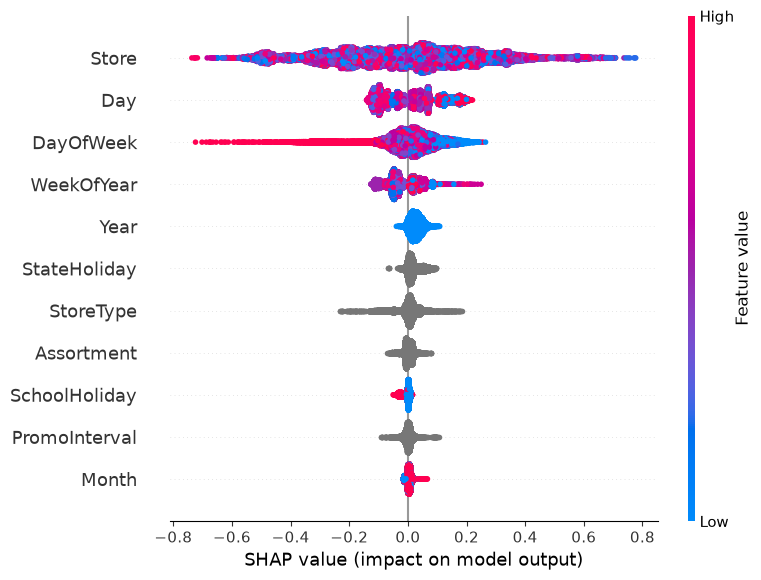

In [12]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(test_data[features])

shap.summary_plot(shap_values, test_data[features])

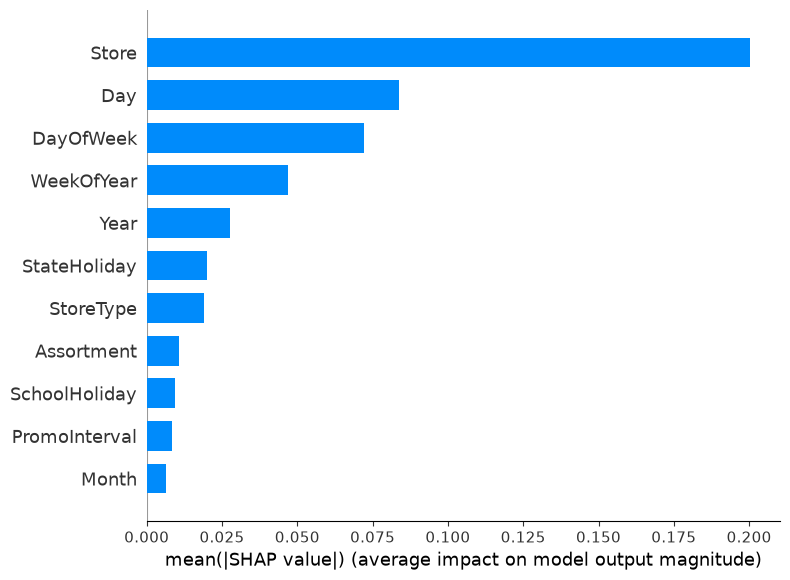

In [13]:
shap.summary_plot(shap_values, test_data[features], plot_type="bar")

In [14]:
import numpy as np

mean_abs = np.abs(shap_values).mean(axis=0)
top5_shap = np.argsort(mean_abs)[::-1][:5]

print("Топ‑5 SHAP:", test_data[features].columns[top5_shap])
print("Топ‑5 CatBoost FI:", final_model.feature_importances_[:5])

Топ‑5 SHAP: Index(['Store', 'Day', 'DayOfWeek', 'WeekOfYear', 'Year'], dtype='str')
Топ‑5 CatBoost FI: [35.65034617 11.13030588  0.53181042  0.75314434  3.29785099]


In [22]:
# предсказания в исходной шкале
preds = np.expm1(final_model.predict(test_pool))
true = np.expm1(test_data['Sales_log'])

# самый высокий прогноз
idx_high = preds.argmax()

# самый низкий прогноз
idx_low = preds.argmin()

# максимальная ошибка
idx_err = np.abs(preds - true).argmax()


In [ ]:
# Современный shap.waterfall_plot() ожидает один объект shap.Explanation, а не три отдельных аргумента.
# Поэтому напишем функцию

def plot_waterfall(idx):
    explanation = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=test_data[features].iloc[idx].values,
        feature_names=features
    )

    shap.waterfall_plot(explanation)

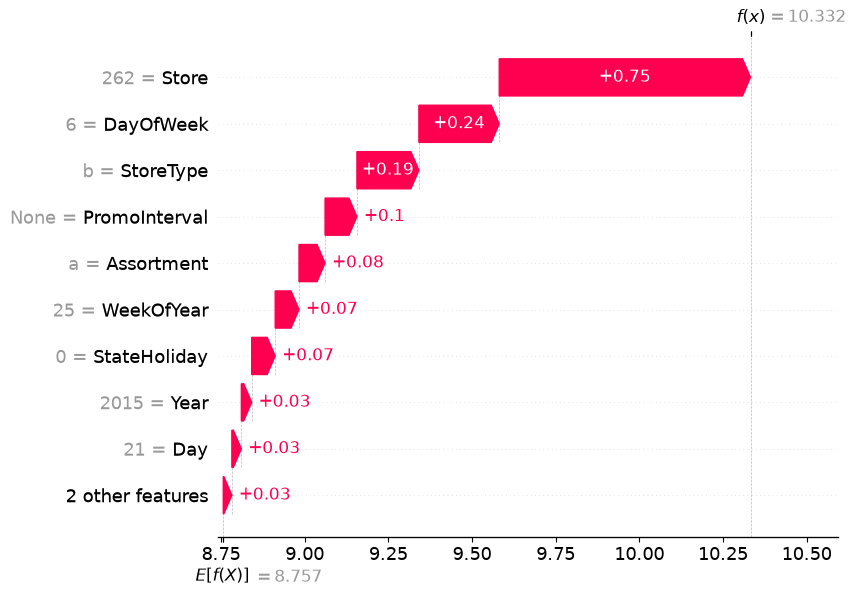

In [24]:
# Самое высокое предсказание
plot_waterfall(idx_high)

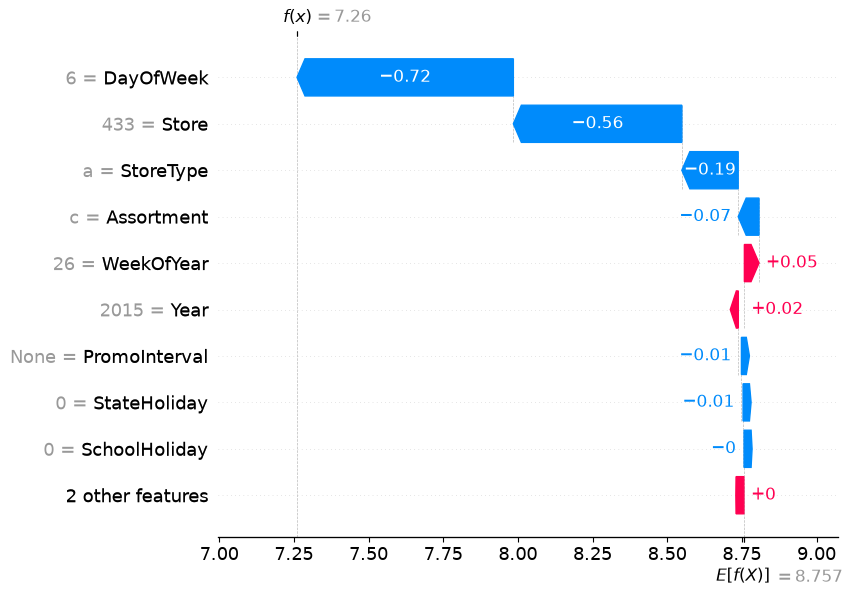

In [25]:
# Самое низкое предсказание
plot_waterfall(idx_low)

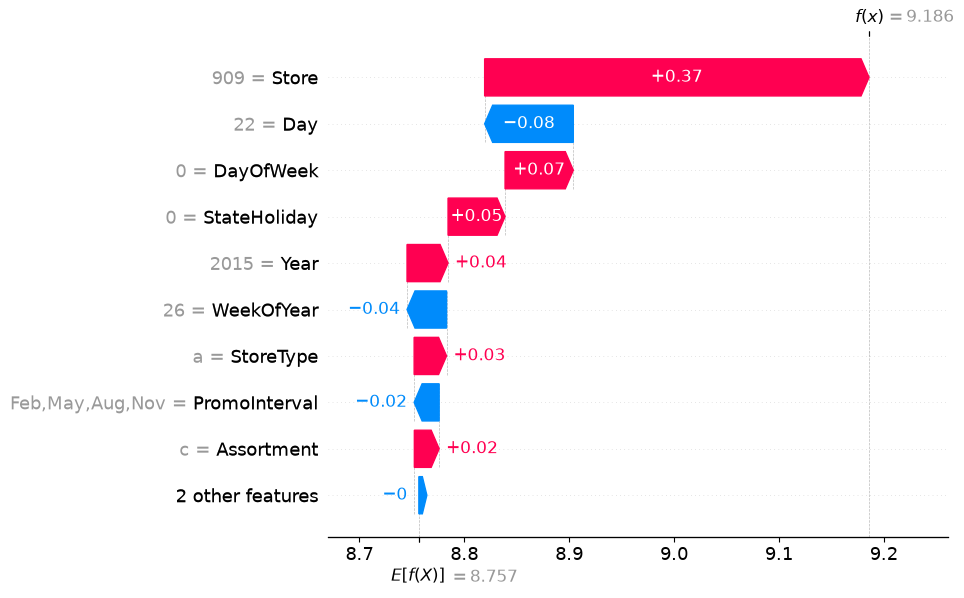

In [26]:
# Самая большая ошибка
plot_waterfall(idx_err)

In [27]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    'feature': features,
    'mean_abs_shap': mean_abs_shap,
}).sort_values('mean_abs_shap', ascending=False)

importance_df.head()

,feature,mean_abs_shap
0,Store,0.200238
9,Day,0.083770
1,DayOfWeek,0.072222
10,WeekOfYear,0.046977
7,Year,0.027718


In [29]:
top_features = importance_df['feature'].head(2).tolist()

print("Топ-2 признака:", top_features)

Топ-2 признака: ['Store', 'Day']


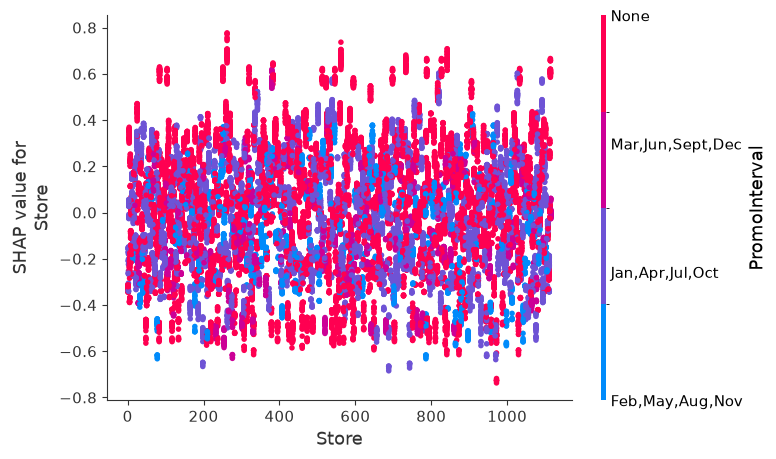

In [30]:
shap.dependence_plot(
    top_features[0],
    shap_values,
    test_data[features]
)

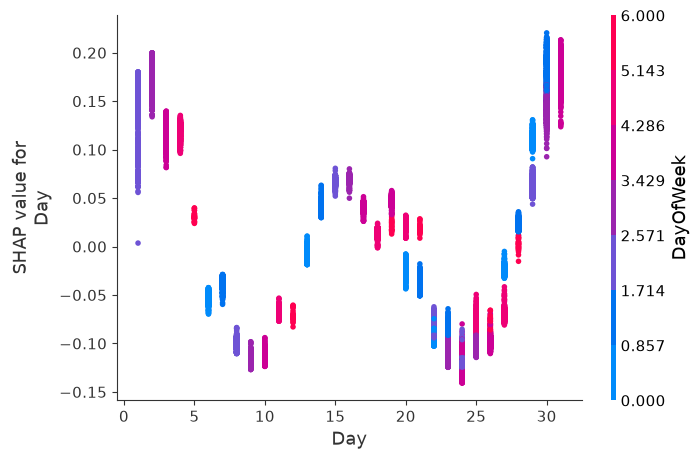

In [31]:
shap.dependence_plot(
    top_features[1],
    shap_values,
    test_data[features]
)

In [34]:
comparison = pd.DataFrame({
    'feature': features,
    'SHAP_importance': np.abs(shap_values).mean(axis=0),
    'CatBoost_importance': final_model.get_feature_importance()
})

comparison = comparison.sort_values(
    'SHAP_importance',
    ascending=False
)

comparison

,feature,SHAP_importance,CatBoost_importance
0,Store,0.200238,35.650346
9,Day,0.083770,18.372331
1,DayOfWeek,0.072222,11.130306
10,WeekOfYear,0.046977,18.428722
7,Year,0.027718,7.353694
2,StateHoliday,0.019871,0.531810
4,StoreType,0.019138,3.297851
5,Assortment,0.010669,0.917303
3,SchoolHoliday,0.009264,0.753144
6,PromoInterval,0.008283,1.037653


In [35]:
print("Топ-5 по SHAP:")
print(comparison.head(5)[['feature', 'SHAP_importance']])

print("\nТоп-5 по CatBoost:")
print(
    comparison
    .sort_values('CatBoost_importance', ascending=False)
    .head(5)[['feature', 'CatBoost_importance']]
)

Топ-5 по SHAP:
       feature  SHAP_importance
0        Store         0.200238
9          Day         0.083770
1    DayOfWeek         0.072222
10  WeekOfYear         0.046977
7         Year         0.027718

Топ-5 по CatBoost:
       feature  CatBoost_importance
0        Store            35.650346
10  WeekOfYear            18.428722
9          Day            18.372331
1    DayOfWeek            11.130306
7         Year             7.353694


Анализ важности признаков показал, что наиболее значимым признаком для модели является `Store`. Он занимает первое место как по SHAP, так и по встроенной оценке важности CatBoost. Это говорит о существенных различиях в уровне продаж между отдельными магазинами.

Остальные признаки из топ-5 также полностью совпадают в обоих методах: `Day`, `DayOfWeek`, `WeekOfYear` и `Year`. При этом порядок `Day`, `DayOfWeek` и `WeekOfYear` немного различается.

Таким образом, SHAP-интерпретация и `feature_importances_` CatBoost дают согласующиеся результаты относительно наиболее важных признаков. При этом значения этих показателей нельзя сравнивать напрямую, поскольку методы используют разные определения важности и разные шкалы.